In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.colorbar as colorbar
from sklearn.manifold import TSNE
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import mpld3
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import zscore
import seaborn as sns
import torch
from scipy.spatial.distance import pdist, squareform
%matplotlib inline

In [2]:
data = np.load(r'dataset/sony_watch/data_20_120.npy')
print(data.shape)
labels = np.load(r'dataset/sony_watch/label_20_120.npy')
print(labels.shape)
label = labels[:,0,0]
print(label.shape)

(3251, 120, 6)
(3251, 120, 2)
(3251,)


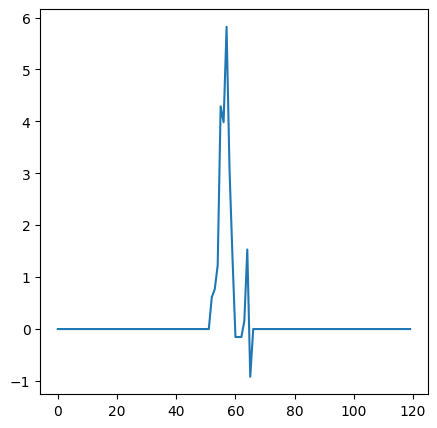

In [8]:
# plot the data
fig = plt.figure(figsize=(5, 5))
d = data[5,:,0]
plt.plot(d)
plt.show()

In [3]:
#print unique label counts
unique, counts = np.unique(label, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(1): np.int64(160), np.int64(2): np.int64(161), np.int64(3): np.int64(166), np.int64(4): np.int64(166), np.int64(5): np.int64(160), np.int64(6): np.int64(164), np.int64(7): np.int64(161), np.int64(8): np.int64(164), np.int64(9): np.int64(161), np.int64(10): np.int64(164), np.int64(11): np.int64(162), np.int64(12): np.int64(161), np.int64(13): np.int64(161), np.int64(14): np.int64(168), np.int64(15): np.int64(162), np.int64(16): np.int64(161), np.int64(17): np.int64(163), np.int64(18): np.int64(163), np.int64(19): np.int64(162), np.int64(20): np.int64(161)}


In [5]:
#print unique label counts
unique, counts = np.unique(label, return_counts=True)
print(dict(zip(unique, counts)))

{1: 72, 2: 98, 3: 98, 4: 99, 5: 98, 6: 103, 7: 101, 8: 100, 9: 100, 10: 104, 11: 92, 12: 100}


In [4]:
def compute_energy(seqs):
    """
    Compute energy of the input sequence.
    Args:
        seqs: Tensor (batch_size, seq_len, feature_size) representing IMU sequences.
    
    Returns:
        energy: A list or tensor representing the energy of the sequence.
    """
    energy = torch.sqrt((seqs ** 2).sum(dim=-1))  # Simple norm-based energy calculation
    return energy


def detect_nucleus(energy, window=20, nucleus_thres=8):
    """
    Detects the nucleus of gestures based on changes in signal energy.

    Parameters:
    - energy: Tensor (batch_size, sequence_length) containing energy values
    - window: int, window size for detecting changes
    - nucleus_thres: float, threshold for significant energy change
    
    Returns:
    - filtered_change_pts: list of lists, each containing start and end points of the nucleus for each sequence
    """
    batch_nucleus_points = []

    # Loop over each sequence in the batch
    for sequence_energy in energy:
        change_pts = []

        # Convert each sequence to a list of scalars (optional if already 1D)
        sequence_energy = sequence_energy.cpu().numpy() if sequence_energy.is_cuda else sequence_energy.numpy()

        # Sliding window to detect energy changes
        for i in range(len(sequence_energy) - 15):
            if abs(sequence_energy[i + 15] - sequence_energy[i]) > nucleus_thres:
                change_pts.append(i)

        # If no change points are detected, use default nucleus points
        if not change_pts:
            filtered_change_pts = [0, min(len(sequence_energy), window)]
        else:
            # Adjust detected change points
            change_pts = list(map(lambda x: x + window, change_pts))
            
            # Filter close change points
            filtered_change_pts = [change_pts[0]]
            for i in range(1, len(change_pts)):
                if change_pts[i] - filtered_change_pts[-1] >= window:
                    filtered_change_pts.append(change_pts[i])

            filtered_change_pts = filtered_change_pts[:2]

            # Adjust if only one change point detected
            if len(filtered_change_pts) == 1:
                filtered_change_pts.append(change_pts[-1] + 10)

        batch_nucleus_points.append(filtered_change_pts)

    return batch_nucleus_points

In [5]:
def adaptive_detect_nucleus(energy, min_nucleus_width=15, max_nucleus_width=40):
    """
    Adaptive nucleus detection that works across different energy profiles.
    
    Parameters:
    - energy: Tensor (batch_size, sequence_length) containing energy values
    - min_nucleus_width: Minimum width of the nucleus region
    - max_nucleus_width: Maximum width of the nucleus region
    
    Returns:
    - batch_nucleus_points: list of lists, each containing start and end points of the nucleus
    """
    batch_nucleus_points = []
    
    # Loop over each sequence in the batch
    for sequence_energy in energy:
        # Convert to numpy for easier manipulation
        if isinstance(sequence_energy, torch.Tensor):
            if sequence_energy.is_cuda:
                sequence_energy = sequence_energy.cpu().numpy()
            elif hasattr(sequence_energy, 'device') and sequence_energy.device.type == 'mps':
                sequence_energy = sequence_energy.to('cpu').numpy()
            else:
                sequence_energy = sequence_energy.numpy()
        
        # Get sequence length and normalize energy to [0,1]
        seq_len = len(sequence_energy)
        energy_min = np.min(sequence_energy)
        energy_max = np.max(sequence_energy)
        
        # Handle flat energy case
        if energy_max - energy_min < 1e-6:
            # Default to the middle section if energy is flat
            mid_point = seq_len // 2
            nucleus_points = [
                max(0, mid_point - min_nucleus_width//2),
                min(seq_len, mid_point + min_nucleus_width//2)
            ]
            batch_nucleus_points.append(nucleus_points)
            continue
        
        # Normalize energy
        norm_energy = (sequence_energy - energy_min) / (energy_max - energy_min)
        
        # Compute gradient (first derivative)
        gradient = np.gradient(norm_energy)
        
        # Find significant transitions (large gradient values)
        abs_gradient = np.abs(gradient)
        gradient_threshold = np.percentile(abs_gradient, 90)  # Adaptive threshold
        
        # Find indices where gradient exceeds threshold
        significant_changes = np.where(abs_gradient > gradient_threshold)[0]
        
        if len(significant_changes) < 2:
            # Not enough significant changes, use energy-based approach
            # Find where energy exceeds half of its range
            active_indices = np.where(norm_energy > 0.5)[0]
            
            if len(active_indices) > 0:
                # Use the active region as nucleus
                start = max(0, active_indices[0])
                end = min(seq_len, active_indices[-1] + 1)
                
                # Ensure minimum width
                if end - start < min_nucleus_width:
                    mid = (start + end) // 2
                    start = max(0, mid - min_nucleus_width // 2)
                    end = min(seq_len, mid + min_nucleus_width // 2)
                
                # Limit maximum width
                if end - start > max_nucleus_width:
                    mid = (start + end) // 2
                    start = max(0, mid - max_nucleus_width // 2)
                    end = min(seq_len, mid + max_nucleus_width // 2)
                
                nucleus_points = [start, end]
            else:
                # Default to the middle if no active region
                mid_point = seq_len // 2
                nucleus_points = [
                    max(0, mid_point - min_nucleus_width//2),
                    min(seq_len, mid_point + min_nucleus_width//2)
                ]
        else:
            # At least two significant changes detected
            # Use the first and last significant changes as boundaries
            transitions = []
            
            # Group consecutive change points
            current_group = [significant_changes[0]]
            for i in range(1, len(significant_changes)):
                if significant_changes[i] - significant_changes[i-1] <= 3:  # Consider consecutive if within 3 time steps
                    current_group.append(significant_changes[i])
                else:
                    transitions.append(np.mean(current_group))
                    current_group = [significant_changes[i]]
            
            if current_group:
                transitions.append(np.mean(current_group))
            
            # Use the first and last transition points if we have at least two
            if len(transitions) >= 2:
                start = max(0, int(transitions[0]))
                end = min(seq_len, int(transitions[-1]))
            else:
                # If only one transition, look at energy levels before and after
                transition = int(transitions[0])
                if np.mean(norm_energy[:transition]) > np.mean(norm_energy[transition:]):
                    # Higher energy before transition
                    start = 0
                    end = min(transition + min_nucleus_width//2, seq_len)
                else:
                    # Higher energy after transition
                    start = max(0, transition - min_nucleus_width//2)
                    end = min(seq_len, seq_len)
            
            # Ensure minimum width
            if end - start < min_nucleus_width:
                mid = (start + end) // 2
                start = max(0, mid - min_nucleus_width // 2)
                end = min(seq_len, mid + min_nucleus_width // 2)
            
            # Limit maximum width
            if end - start > max_nucleus_width:
                mid = (start + end) // 2
                start = max(0, mid - max_nucleus_width // 2)
                end = min(seq_len, mid + max_nucleus_width // 2)
            
            nucleus_points = [start, end]
        
        batch_nucleus_points.append(nucleus_points)
    
    return batch_nucleus_points

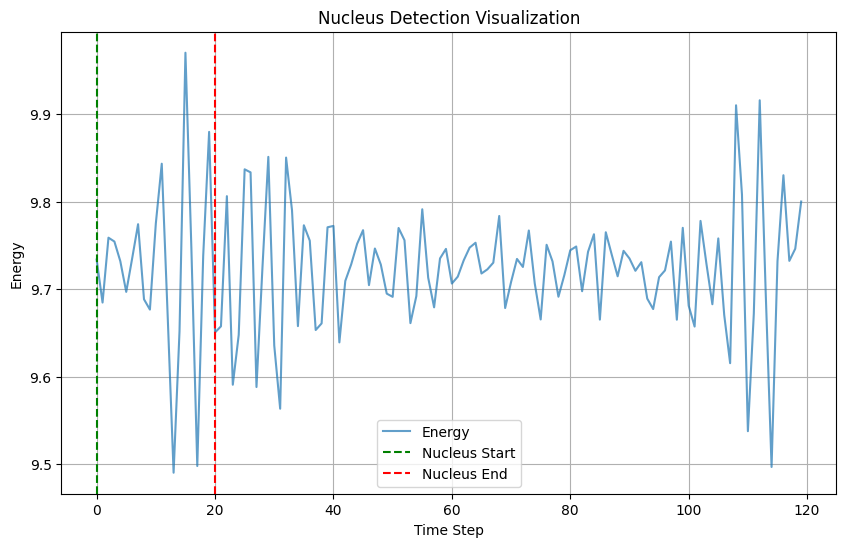

In [16]:
# Load example data
data_file = r'dataset/hhar/data_20_120.npy'  # Replace with the actual .npy file path
data = np.load(data_file)  # Load your .npy file

# Convert data to a PyTorch tensor
data_tensor = torch.tensor(data)

# Compute energy
energy = compute_energy(data_tensor)

# Detect nucleus
nucleus_points = detect_nucleus(energy)

# Visualize data with nucleus points
sample_size = 1  # Define the sample size
sample_index = np.random.choice(data.shape[0], sample_size, replace=False)[0]

sequence_energy = energy[sample_index].numpy()
nucleus_start, nucleus_end = nucleus_points[sample_index]

plt.figure(figsize=(10, 6))
plt.plot(sequence_energy, label='Energy', alpha=0.7)
plt.axvline(x=nucleus_start, color='green', linestyle='--', label='Nucleus Start')
plt.axvline(x=nucleus_end, color='red', linestyle='--', label='Nucleus End')
plt.title('Nucleus Detection Visualization')
plt.xlabel('Time Step')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)
plt.show()

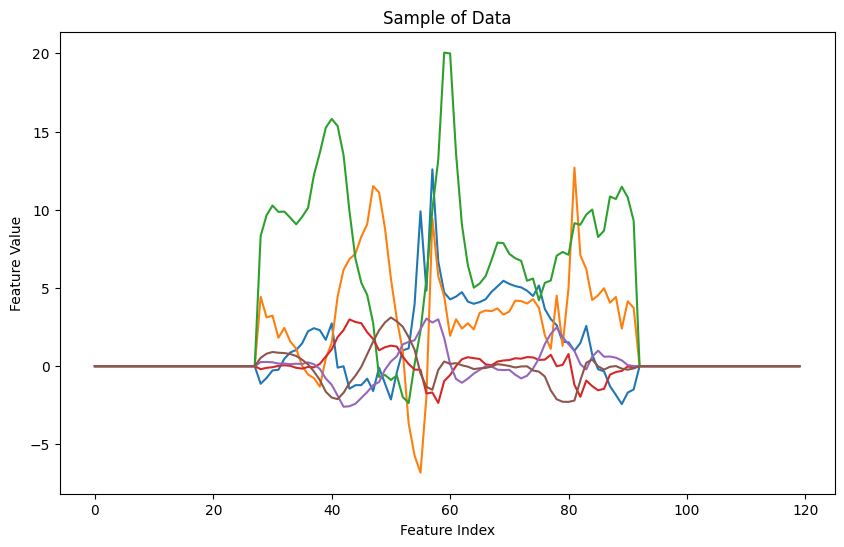

In [55]:
sample_data = data[sample_index:sample_index+120]

plt.figure(figsize=(10, 6))
for i in range(sample_size):
    plt.plot(sample_data[i], label=f'Sample {i+1}')
plt.title('Sample of Data')
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.show()

In [6]:
unique_labels = np.unique(label)
print(unique_labels)
label_dict = {}

for i in unique_labels:
    label_dict[i] = []

for i in range(len(label)):
    label_dict[label[i]].append(i)
print(label_dict)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
{np.int64(1): [31, 41, 50, 51, 60, 61, 71, 72, 76, 79, 172, 182, 191, 192, 201, 202, 212, 213, 218, 222, 322, 480, 490, 500, 501, 506, 510, 743, 754, 763, 764, 773, 774, 784, 785, 790, 794, 895, 905, 914, 915, 923, 924, 935, 936, 941, 945, 1045, 1055, 1064, 1065, 1074, 1075, 1086, 1087, 1092, 1096, 1192, 1202, 1209, 1216, 1226, 1316, 1326, 1335, 1336, 1345, 1346, 1356, 1357, 1362, 1366], np.int64(2): [3, 11, 12, 17, 18, 21, 26, 29, 104, 109, 144, 152, 153, 158, 159, 162, 167, 170, 253, 258, 294, 302, 303, 308, 309, 312, 317, 320, 397, 433, 441, 442, 447, 448, 451, 456, 459, 538, 543, 579, 587, 588, 593, 594, 597, 602, 605, 674, 679, 715, 723, 724, 729, 730, 733, 738, 741, 825, 830, 867, 875, 876, 881, 882, 885, 890, 893, 976, 981, 1017, 1025, 1026, 1031, 1032, 1035, 1040, 1043, 1126, 1131, 1173, 1174, 1179, 1180, 1183, 1187, 1190, 1251, 1256, 1288, 1296, 1297, 1302, 1303, 1306, 1311, 1314, 1397, 1404], np.int64(3): [32, 40, 49, 52, 59, 63,

In [ ]:
embed = np.load('embed/embed_limu_v1_earbud_filtered_20_120.npy')
print(embed.shape)
# drop second dimension

#embed = embed[:,30,:]
embed = embed.mean(axis=1) #avg over 120 frames
pca = PCA(n_components=3)
pca.fit(embed)
embed_pca = pca.transform(embed)
print(embed_pca.shape)


(1439, 120, 72)
(1439, 3)


In [10]:
tsne = TSNE(n_components=3)
# Fit and transform the data
embed_tsne = tsne.fit_transform(embed)

labels = np.load(r'dataset/earbud_filtered/label_20_120.npy')
print(labels.shape)
label = labels[:,0,0]
unique_labels = np.unique(label)
print(unique_labels)
label_dict = {}

for i in unique_labels:
    label_dict[i] = []

for i in range(len(label)):
    label_dict[label[i]].append(i)
print(label_dict)


(368, 120, 2)
[1 2 3 4 5 6 7]
{np.int64(1): [0, 1, 42, 44, 50, 60, 61, 71, 72, 79, 85, 86, 88, 90, 94, 97, 98, 103, 104, 110, 112, 156, 161, 165, 171, 175, 178, 207, 261, 267, 269, 275, 285, 286, 296, 297, 304, 310, 311, 313, 315, 319, 322, 323, 328, 329, 335, 337], np.int64(2): [4, 5, 6, 12, 13, 15, 16, 22, 23, 25, 27, 32, 33, 34, 35, 117, 120, 123, 130, 132, 142, 145, 146, 153, 154, 193, 195, 196, 201, 215, 228, 229, 230, 236, 237, 239, 240, 246, 247, 249, 251, 256, 257, 258, 259, 342, 345, 348, 355, 357], np.int64(3): [38, 47, 48, 58, 63, 69, 74, 75, 82, 84, 87, 92, 95, 96, 99, 100, 101, 106, 107, 114, 157, 160, 164, 166, 170, 203, 206, 210, 263, 272, 273, 283, 288, 294, 299, 300, 307, 309, 312, 317, 320, 321, 324, 325, 326, 331, 332, 339], np.int64(4): [3, 7, 10, 18, 28, 31, 36, 37, 49, 51, 59, 62, 70, 73, 83, 93, 108, 115, 127, 134, 144, 147, 149, 152, 155, 176, 177, 179, 180, 200, 202, 227, 231, 234, 242, 252, 255, 260, 262, 274, 276, 284, 287, 295, 298, 308, 318, 333, 340, 352, 

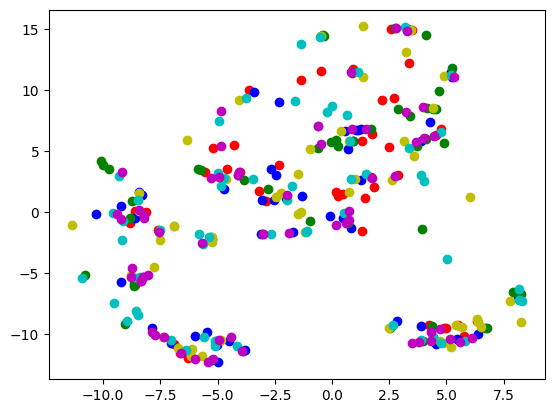

In [11]:

fig = plt.figure()
ax = fig.add_subplot(111)
for i in label_dict[1]:
    ax.scatter(embed_tsne[i,0], embed_tsne[i,1], c='r', marker='o')
for i in label_dict[2]:
    ax.scatter(embed_tsne[i,0], embed_tsne[i,1], c='b', marker='o')
for i in label_dict[3]:
    ax.scatter(embed_tsne[i,0], embed_tsne[i,1], c='g', marker='o')
for i in label_dict[4]:
    ax.scatter(embed_tsne[i,0], embed_tsne[i,1], c='y', marker='o')
for i in label_dict[5]:
    ax.scatter(embed_tsne[i,0], embed_tsne[i,1], c='c', marker='o')
for i in label_dict[6]:
    ax.scatter(embed_tsne[i,0], embed_tsne[i,1], c='m', marker='o')

plt.show()

(1165, 120, 72)
(1165, 120, 2)
Unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]
{np.int64(1): [28, 38, 44, 45, 54, 55, 63, 64, 67, 69, 147, 157, 163, 164, 173, 174, 182, 183, 186, 188, 267, 393, 403, 411, 412, 415, 417, 602, 613, 619, 620, 629, 630, 638, 639, 642, 644, 724, 734, 740, 741, 749, 750, 759, 760, 763, 765, 844, 854, 860, 861, 870, 871, 880, 881, 884, 886, 962, 972, 978, 985, 993, 1069, 1079, 1085, 1086, 1095, 1096, 1104, 1105, 1108, 1110], np.int64(2): [2, 8, 9, 14, 15, 18, 23, 26, 88, 93, 121, 127, 128, 133, 134, 137, 142, 145, 208, 213, 241, 247, 248, 253, 254, 257, 262, 265, 323, 351, 357, 358, 363, 364, 367, 372, 375, 435, 440, 469, 475, 476, 481, 482, 485, 490, 493, 543, 548, 576, 582, 583, 588, 589, 592, 597, 600, 664, 669, 698, 704, 705, 710, 711, 714, 719, 722, 785, 790, 818, 824, 825, 830, 831, 834, 839, 842, 905, 910, 943, 944, 949, 950, 953, 957, 960, 1011, 1016, 1043, 1049, 1050, 1055, 1056, 1059, 1064, 1067, 1130, 1137], np.int64(3): [29, 37, 43, 46, 53, 56

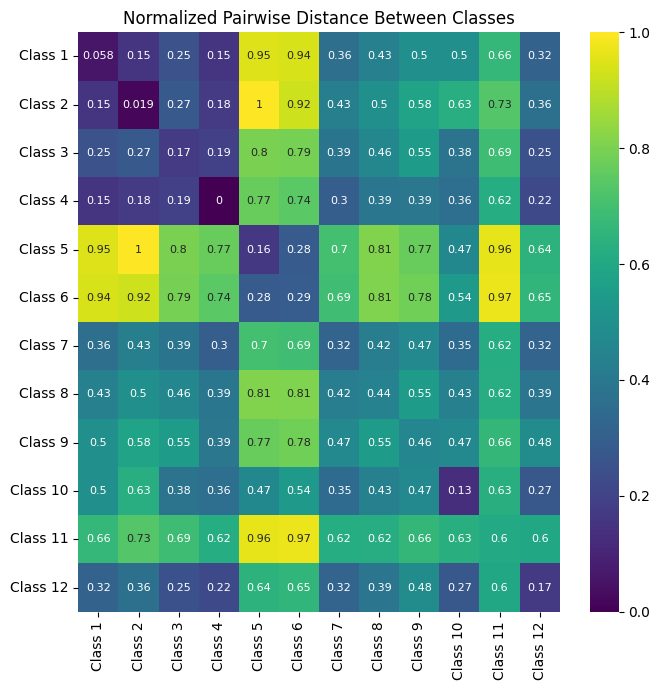

Class 1: 0.0584
Class 2: 0.0187
Class 3: 0.1720
Class 4: 0.0000
Class 5: 0.1618
Class 6: 0.2894
Class 7: 0.3187
Class 8: 0.4395
Class 9: 0.4596
Class 10: 0.1313
Class 11: 0.6047
Class 12: 0.1678
Silhouette Score: -0.0296


In [15]:
# Load your data as before
dataset = 'blind_user_filtered'
embed = np.load('embed/embed_limu_v1_' + dataset + '_20_120.npy')
print(embed.shape)
embed = embed.mean(axis=1)  # avg over 120 frames

"""# PCA for visualization
pca = PCA(n_components=3)
pca.fit(embed)
embed_pca = pca.transform(embed)
print(embed_pca.shape)

# t-SNE for visualization
tsne = TSNE(n_components=3)
embed_tsne = tsne.fit_transform(embed)"""
embed_tsne = embed

# Load labels
labels = np.load('dataset/' + dataset + '/label_20_120.npy')
print(labels.shape)
label = labels[:,0,0]
unique_labels = np.unique(label)
print(f"Unique labels: {unique_labels}")
n_classes = len(unique_labels)

# Create dictionary mapping label to indices
label_dict = {}
for i in unique_labels:
    label_dict[i] = []

for i in range(len(label)):
    label_dict[label[i]].append(i)
print(label_dict)

# Calculate centroid for each class
centroids = {}
for label_id in unique_labels:
    indices = label_dict[label_id]
    centroids[label_id] = np.mean(embed[indices], axis=0)

# Function to calculate the average pairwise distance between classes
def calculate_class_distances(embed, label_dict, distance_metric='euclidean'):
    """
    Calculate the average pairwise distance between class instances
    
    Args:
        embed: embedding matrix (n_samples, n_features)
        label_dict: dictionary mapping labels to indices
        distance_metric: distance metric to use (default: euclidean)
        
    Returns:
        distance_matrix: normalized distance matrix (n_classes, n_classes)
    """
    unique_labels = list(label_dict.keys())
    n_classes = len(unique_labels)
    distance_matrix = np.zeros((n_classes, n_classes))
    
    # Calculate distances between classes
    for i, label_i in enumerate(unique_labels):
        indices_i = label_dict[label_i]
        embed_i = embed[indices_i]
        
        for j, label_j in enumerate(unique_labels):
            indices_j = label_dict[label_j]
            embed_j = embed[indices_j]
            
            # Calculate average distance between all pairs of points from both classes
            distances = []
            for idx_i in range(len(indices_i)):
                for idx_j in range(len(indices_j)):
                    # Skip self-comparisons for same class
                    if label_i == label_j and idx_i == idx_j:
                        continue
                    dist = np.linalg.norm(embed_i[idx_i] - embed_j[idx_j])
                    distances.append(dist)
            
            distance_matrix[i, j] = np.mean(distances)
    
    # Normalize distance matrix (min-max normalization)
    min_dist = np.min(distance_matrix)
    max_dist = np.max(distance_matrix)
    normalized_dist_matrix = (distance_matrix - min_dist) / (max_dist - min_dist)
    
    return normalized_dist_matrix, unique_labels

# Calculate distance matrix
dist_matrix, sorted_labels = calculate_class_distances(embed, label_dict)

# Plot original t-SNE scatter plot
plt.figure(figsize=(7, 7))
sns.heatmap(dist_matrix, annot=True, cmap='viridis', 
            xticklabels=[f'Class {l}' for l in sorted_labels],
            yticklabels=[f'Class {l}' for l in sorted_labels],
            annot_kws={"fontsize":8})
# reduce the size of text inside the heatmap
plt.title('Normalized Pairwise Distance Between Classes')
plt.tight_layout()

# Save figure
plt.savefig('embedding_class_distances.png', dpi=300, bbox_inches='tight')
plt.show()

#print the diagonal of the distance matrix
for i in range(dist_matrix.shape[0]):
    print(f"Class {i+1}: {dist_matrix[i,i]:.4f}")


# Optional: Calculate silhouette score to measure cluster separation
from sklearn.metrics import silhouette_score
try:
    silhouette_avg = silhouette_score(embed, label)
    print(f"Silhouette Score: {silhouette_avg:.4f}")
except:
    print("Couldn't calculate silhouette score (possibly due to only one sample per label)")

Weights normalized to sum to 1.0: w1=0.444, w2=0.333, w3=0.222

Classes ranked by Weighted Ensemble Score:
       Class  Weighted Ensemble Score  Avg Separation Ratio  \
3    Class 4               778.000000                   inf   
1    Class 2                15.342118             27.924688   
0    Class 1                 4.687091              8.114958   
4    Class 5                 2.801173              4.577032   
9   Class 10                 2.423516              3.473692   
2    Class 3                 1.729934              2.654945   
11  Class 12                 1.704086              2.435946   
5    Class 6                 1.617063              2.552881   
6    Class 7                 1.101072              1.438413   
7    Class 8                 0.955522              1.203484   
8    Class 9                 0.952011              1.227620   
10  Class 11                 0.934895              1.167476   

    Min Separation Ratio  Cohesion Score  
3                    inf      

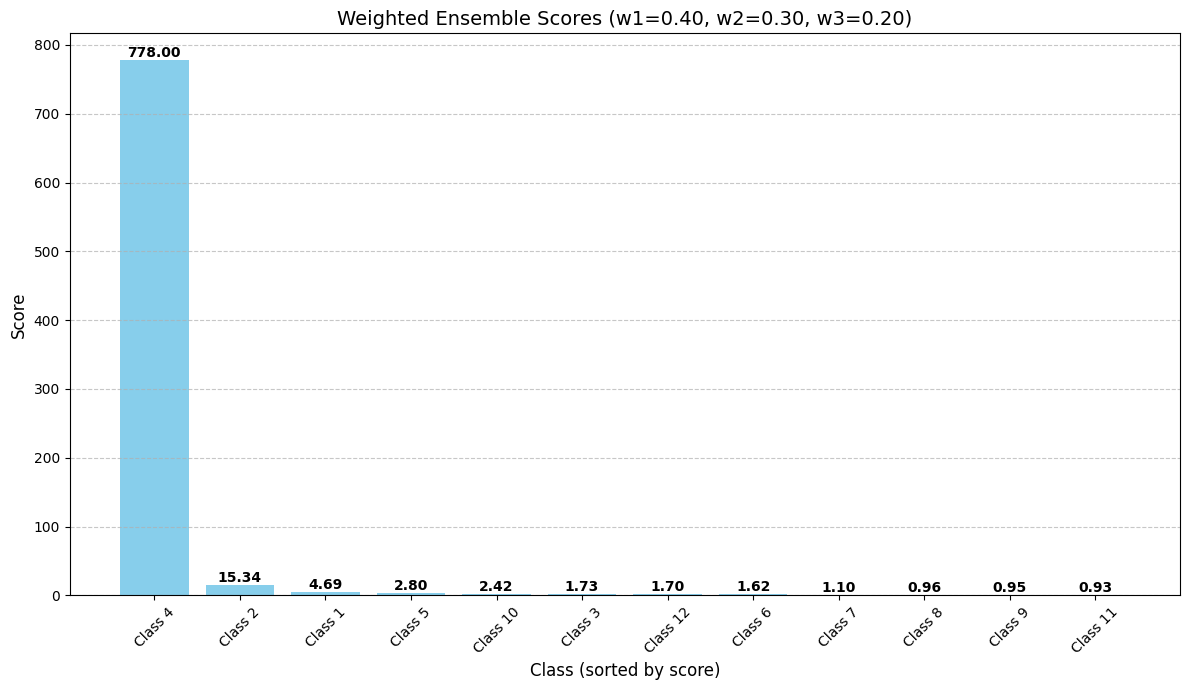

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


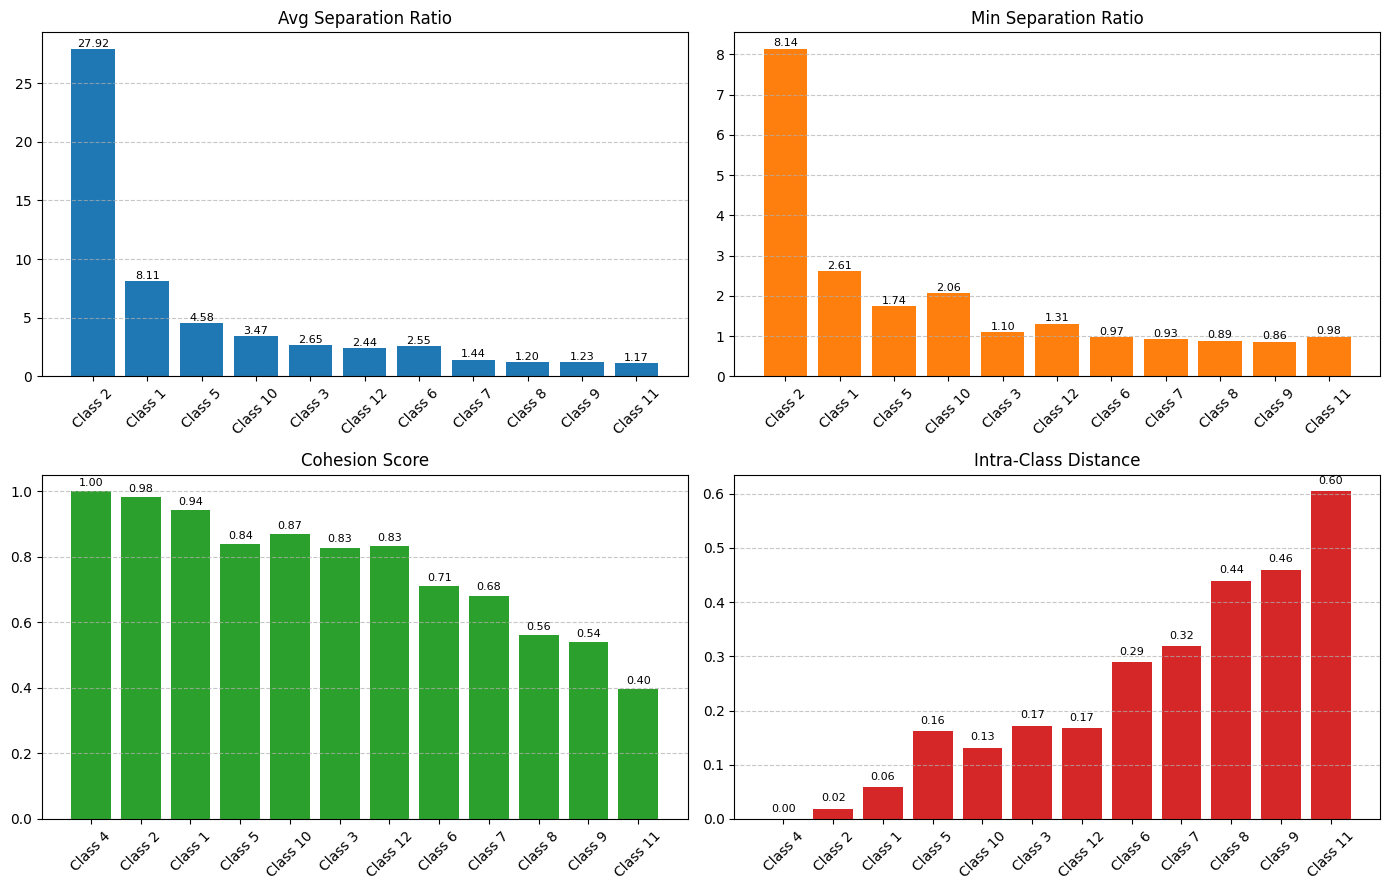

In [16]:
def calculate_weighted_ensemble_scores(distance_matrix, w1=0.4, w2=0.4, w3=0.2):
    """
    Calculate the Weighted Ensemble Score for each class in a distance matrix.
    
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        An n x n matrix where element [i,j] represents the distance between class i and class j.
        Diagonal elements represent intra-class distances.
    w1 : float
        Weight for the average separation ratio (default: 0.4)
    w2 : float
        Weight for the minimum separation ratio (default: 0.4)
    w3 : float
        Weight for the cohesion score (default: 0.2)
    
    Returns:
    --------
    scores : numpy.ndarray
        Array of Weighted Ensemble Scores for each class
    metrics : pandas.DataFrame
        DataFrame containing all the component metrics and final scores
    """
    # Ensure weights sum to 1
    total_weight = w1 + w2 + w3
    if abs(total_weight - 1.0) > 1e-10:
        w1, w2, w3 = w1/total_weight, w2/total_weight, w3/total_weight
        print(f"Weights normalized to sum to 1.0: w1={w1:.3f}, w2={w2:.3f}, w3={w3:.3f}")
    
    n_classes = distance_matrix.shape[0]
    
    # Initialize arrays to store metrics
    avg_separation_ratios = np.zeros(n_classes)
    min_separation_ratios = np.zeros(n_classes)
    cohesion_scores = np.zeros(n_classes)
    weighted_scores = np.zeros(n_classes)
    
    for i in range(n_classes):
        # Get intra-class distance (diagonal element)
        intra_distance = distance_matrix[i, i]
        
        # Get inter-class distances (off-diagonal elements in row i)
        inter_distances = np.concatenate([distance_matrix[i, :i], distance_matrix[i, i+1:]])
        
        # Calculate average inter-class distance
        avg_inter_distance = np.mean(inter_distances)
        
        # Calculate minimum inter-class distance
        min_inter_distance = np.min(inter_distances)
        
        # Calculate component metrics
        # Handle potential division by zero for perfect cohesion (intra_distance = 0)
        if intra_distance == 0:
            avg_separation_ratio = float('inf')  # or use a large number like 1000
            min_separation_ratio = float('inf')  # or use a large number like 1000
        else:
            avg_separation_ratio = avg_inter_distance / intra_distance
            min_separation_ratio = min_inter_distance / intra_distance
            
        cohesion_score = 1 - intra_distance
        
        # Calculate weighted ensemble score
        # If infinity, use a large finite number for calculation
        avg_ratio_term = 1000 if np.isinf(avg_separation_ratio) else avg_separation_ratio
        min_ratio_term = 1000 if np.isinf(min_separation_ratio) else min_separation_ratio
        
        weighted_score = w1 * avg_ratio_term + w2 * min_ratio_term + w3 * cohesion_score
        
        # Store values
        avg_separation_ratios[i] = avg_separation_ratio
        min_separation_ratios[i] = min_separation_ratio
        cohesion_scores[i] = cohesion_score
        weighted_scores[i] = weighted_score
    
    # Create DataFrame with all metrics
    metrics_df = pd.DataFrame({
        'Class': [f'Class {i+1}' for i in range(n_classes)],
        'Intra-Class Distance': np.diag(distance_matrix),
        'Avg Inter-Class Distance': [np.mean(np.concatenate([distance_matrix[i, :i], distance_matrix[i, i+1:]])) for i in range(n_classes)],
        'Min Inter-Class Distance': [np.min(np.concatenate([distance_matrix[i, :i], distance_matrix[i, i+1:]])) for i in range(n_classes)],
        'Avg Separation Ratio': avg_separation_ratios,
        'Min Separation Ratio': min_separation_ratios,
        'Cohesion Score': cohesion_scores,
        'Weighted Ensemble Score': weighted_scores
    })
    
    return weighted_scores, metrics_df

def visualize_scores(metrics_df, weights):
    """
    Visualize the Weighted Ensemble Scores and their components.
    
    Parameters:
    -----------
    metrics_df : pandas.DataFrame
        DataFrame containing metrics as returned by calculate_weighted_ensemble_scores
    weights : tuple
        Tuple of (w1, w2, w3) weights used
    """
    # Sort by weighted score
    sorted_df = metrics_df.sort_values('Weighted Ensemble Score', ascending=False).reset_index(drop=True)
    
    # Plot weighted scores
    plt.figure(figsize=(12, 7))
    
    # Create bar plot
    ax = plt.subplot(111)
    bars = ax.bar(sorted_df['Class'], sorted_df['Weighted Ensemble Score'], color='skyblue')
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Customize plot
    plt.title(f'Weighted Ensemble Scores (w1={weights[0]:.2f}, w2={weights[1]:.2f}, w3={weights[2]:.2f})', fontsize=14)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Class (sorted by score)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Second figure for component metrics
    plt.figure(figsize=(14, 9))
    
    # Select key metrics for display
    display_metrics = ['Avg Separation Ratio', 'Min Separation Ratio', 'Cohesion Score', 'Intra-Class Distance']
    
    # Plot each metric as a subplot
    for i, metric in enumerate(display_metrics):
        plt.subplot(2, 2, i+1)
        bars = plt.bar(sorted_df['Class'], sorted_df[metric], color=plt.cm.tab10(i))
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        
        plt.title(metric)
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()



# Set your desired weights
w1, w2, w3 = 0.4, 0.3, 0.2  # Average ratio, Minimum ratio, Cohesion

# Calculate scores
scores, metrics_df = calculate_weighted_ensemble_scores(dist_matrix, w1, w2, w3)

# Print sorted results
print("\nClasses ranked by Weighted Ensemble Score:")
sorted_metrics = metrics_df.sort_values('Weighted Ensemble Score', ascending=False)
print(sorted_metrics[['Class', 'Weighted Ensemble Score', 'Avg Separation Ratio', 
                        'Min Separation Ratio', 'Cohesion Score']])

# Visualize results
visualize_scores(metrics_df, (w1, w2, w3))

Available gestures by user:
Available gestures in blind_user_filtered dataset by user:
  User 0:
    Gesture ID 1: 10 samples
    Gesture ID 2: 10 samples
    Gesture ID 3: 10 samples
    Gesture ID 4: 10 samples
    Gesture ID 5: 10 samples
    Gesture ID 6: 10 samples
    Gesture ID 7: 10 samples
    Gesture ID 8: 10 samples
    Gesture ID 9: 10 samples
    Gesture ID 10: 10 samples
    Gesture ID 11: 9 samples
    Gesture ID 12: 10 samples
  User 1:
    Gesture ID 1: 10 samples
    Gesture ID 2: 10 samples
    Gesture ID 3: 10 samples
    Gesture ID 4: 10 samples
    Gesture ID 5: 10 samples
    Gesture ID 6: 10 samples
    Gesture ID 7: 10 samples
    Gesture ID 8: 10 samples
    Gesture ID 9: 10 samples
    Gesture ID 10: 10 samples
    Gesture ID 11: 10 samples
    Gesture ID 12: 10 samples
  User 2:
    Gesture ID 1: 1 samples
    Gesture ID 2: 9 samples
    Gesture ID 3: 10 samples
    Gesture ID 4: 9 samples
    Gesture ID 5: 10 samples
    Gesture ID 6: 11 samples
    Gesture

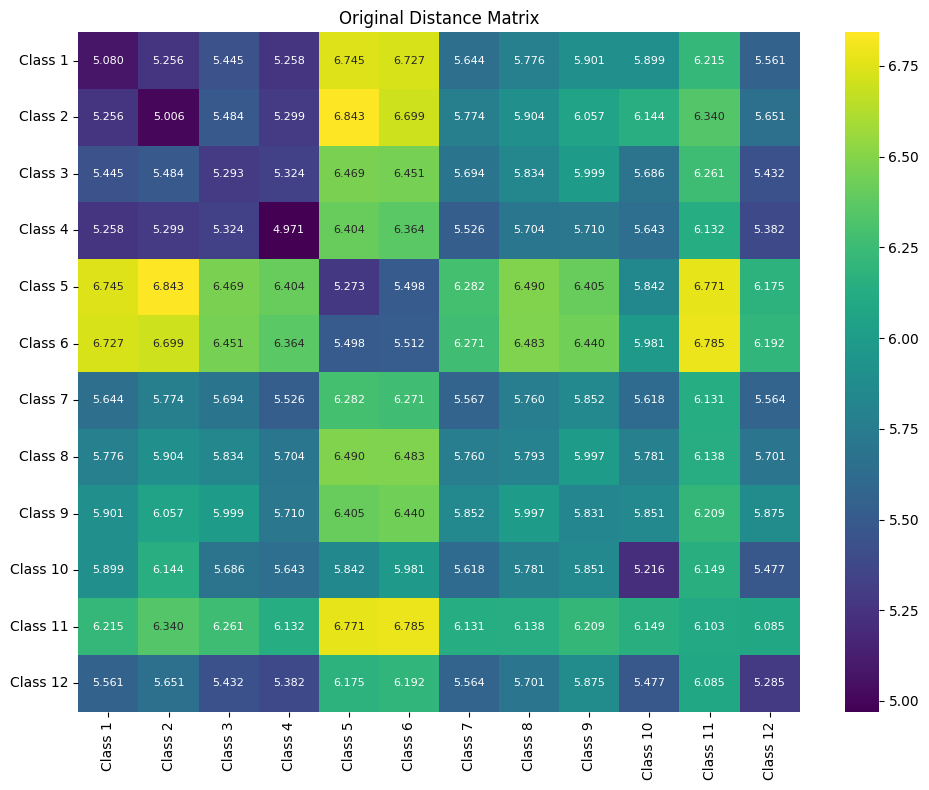


Adding gesture 13 from User 3 in blind_user to blind_user_filtered...
Looking for gesture ID 13 for user 3
Source label shape: (1439, 120, 2)
Unique users in source: [0 1 2 3 4 5 6 7 8 9]
Unique gestures in source: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Found 10 instances of gesture 13 for user 3


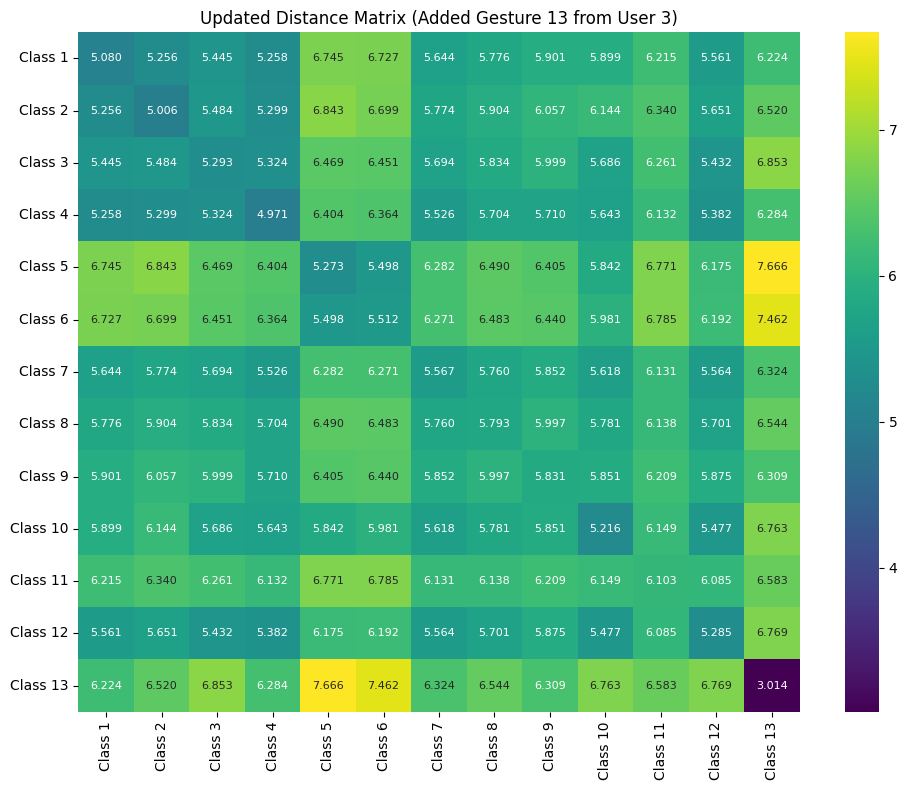

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

def add_new_gesture_from_dataset(filtered_dataset_name, source_dataset_name, gesture_id, user_idx):
    """
    Adds a new gesture from the source dataset to the filtered dataset and updates the distance matrix
    Filters by the specified user_idx (second column in labels.npy)
    
    Args:
        filtered_dataset_name: name of the filtered dataset (e.g., 'blind_user_filtered')
        source_dataset_name: name of the source dataset (e.g., 'blind_user')
        gesture_id: the gesture ID to add from the source dataset
        user_idx: the user index to filter by (from second column of labels.npy)
        
    Returns:
        updated_embed: updated embedding matrix including the new gesture
        updated_label_dict: updated dictionary mapping labels to indices
        updated_dist_matrix: updated distance matrix
        updated_labels: list of updated labels
    """
    # Load filtered dataset
    filtered_embed = np.load(f'embed/embed_limu_v1_{filtered_dataset_name}_20_120.npy')
    filtered_labels = np.load(f'dataset/{filtered_dataset_name}/label_20_120.npy')
    
    # Load source dataset
    source_embed = np.load(f'embed/embed_limu_v1_{source_dataset_name}_20_120.npy')
    source_labels = np.load(f'dataset/{source_dataset_name}/label_20_120.npy')
    
    # Average embeddings over frames (as in your original code)
    filtered_embed = filtered_embed.mean(axis=1)  # avg over 120 frames
    source_embed = source_embed.mean(axis=1)  # avg over 120 frames
    
    print(f"Looking for gesture ID {gesture_id} for user {user_idx}")
    print(f"Source label shape: {source_labels.shape}")
    
    # Get all unique gestures and users from the source dataset
    all_source_gestures = np.unique(source_labels[:, 0, 0])
    all_source_users = np.unique(source_labels[:, 0, 1])
    print(f"Unique users in source: {all_source_users}")
    print(f"Unique gestures in source: {all_source_gestures}")
    
    # Find the indices of samples where the first frame has both the right gesture and user
    # We use the first frame (index 0) since all frames in a sequence have the same label
    gesture_indices = []
    for i in range(len(source_labels)):
        if source_labels[i, 0, 0] == gesture_id and source_labels[i, 0, 1] == user_idx:
            gesture_indices.append(i)
    
    if len(gesture_indices) == 0:
        # Try to find any gestures for this user
        user_gestures = []
        for i in range(len(source_labels)):
            if source_labels[i, 0, 1] == user_idx:
                user_gestures.append(source_labels[i, 0, 0])
        
        user_gestures = np.unique(user_gestures)
        
        if len(user_gestures) > 0:
            print(f"User {user_idx} has gestures {user_gestures} but not gesture {gesture_id}")
        else:
            print(f"User {user_idx} has no gestures in the source dataset")
        
        raise ValueError(f"Gesture ID {gesture_id} not found for user {user_idx} in source dataset")
    
    print(f"Found {len(gesture_indices)} instances of gesture {gesture_id} for user {user_idx}")
    
    # Extract embeddings for the selected gesture from the specific user
    gesture_indices = np.array(gesture_indices)
    gesture_embeddings = source_embed[gesture_indices]
    
    # Create new labels for the added gesture
    gesture_labels = np.full(len(gesture_indices), gesture_id)
    
    # Combine with filtered dataset
    updated_embed = np.vstack((filtered_embed, gesture_embeddings))
    updated_label = np.hstack((filtered_labels[:, 0, 0], gesture_labels))
    
    # Get unique labels in the updated dataset
    unique_labels = np.unique(updated_label)
    
    # Create dictionary mapping label to indices
    label_dict = {}
    for i in unique_labels:
        label_dict[i] = []

    for i in range(len(updated_label)):
        label_dict[updated_label[i]].append(i)
    
    # Calculate the updated distance matrix
    dist_matrix, sorted_labels = calculate_class_distances(updated_embed, label_dict)
    
    return updated_embed, label_dict, dist_matrix, sorted_labels

def calculate_class_distances(embed, label_dict, distance_metric='euclidean'):
    """
    Calculate the average pairwise distance between class instances
    
    Args:
        embed: embedding matrix (n_samples, n_features)
        label_dict: dictionary mapping labels to indices
        distance_metric: distance metric to use (default: euclidean)
        
    Returns:
        distance_matrix: normalized distance matrix (n_classes, n_classes)
        sorted_labels: list of labels in the order they appear in the distance matrix
    """
    unique_labels = list(label_dict.keys())
    n_classes = len(unique_labels)
    distance_matrix = np.zeros((n_classes, n_classes))
    
    # Calculate distances between classes
    for i, label_i in enumerate(unique_labels):
        indices_i = label_dict[label_i]
        embed_i = embed[indices_i]
        
        for j, label_j in enumerate(unique_labels):
            indices_j = label_dict[label_j]
            embed_j = embed[indices_j]
            
            # Calculate average distance between all pairs of points from both classes
            distances = []
            for idx_i in range(len(indices_i)):
                for idx_j in range(len(indices_j)):
                    # Skip self-comparisons for same class
                    if label_i == label_j and idx_i == idx_j:
                        continue
                    dist = np.linalg.norm(embed_i[idx_i] - embed_j[idx_j])
                    distances.append(dist)
            
            distance_matrix[i, j] = np.mean(distances)
    
    # Normalize distance matrix (min-max normalization)
    #min_dist = np.min(distance_matrix)
    #max_dist = np.max(distance_matrix)
    #normalized_dist_matrix = (distance_matrix - min_dist) / (max_dist - min_dist)
    
    return distance_matrix, unique_labels

def visualize_distance_matrix(dist_matrix, labels, title=None, output_file=None):
    """
    Visualize the distance matrix as a heatmap
    
    Args:
        dist_matrix: distance matrix to visualize
        labels: list of labels corresponding to rows/columns in the distance matrix
        title: title for the plot (optional)
        output_file: file to save the plot to (optional)
    """
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(dist_matrix, annot=True, cmap='viridis', 
                xticklabels=[f'Class {l}' for l in labels],
                yticklabels=[f'Class {l}' for l in labels],
                annot_kws={"fontsize":8},
                fmt='.3f')
    
    if title:
        plt.title(title)
    else:
        plt.title('Normalized Pairwise Distance Between Classes')
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    plt.show()

def list_available_gestures_by_user(dataset_name):
    """
    List available gestures in a dataset, organized by user
    
    Args:
        dataset_name: name of the dataset to list gestures from
    
    Returns:
        user_gesture_dict: dictionary mapping users to their available gestures
    """
    labels = np.load(f'dataset/{dataset_name}/label_20_120.npy')
    
    # Extract gesture IDs and user IDs from the first frame (since all frames in a sequence have the same label)
    gesture_ids = labels[:, 0, 0]  # First column for gesture IDs
    user_ids = labels[:, 0, 1]     # Second column for user IDs
    
    # Get unique users
    unique_users = np.unique(user_ids)
    
    # Create dictionary to store gestures for each user
    user_gesture_dict = {}
    
    print(f"Available gestures in {dataset_name} dataset by user:")
    for user in unique_users:
        # Find indices for this user
        user_indices = np.where(user_ids == user)[0]
        
        # Get gesture IDs for this user
        user_gestures = gesture_ids[user_indices]
        
        # Count occurrences of each gesture
        unique_gestures, counts = np.unique(user_gestures, return_counts=True)
        
        # Store in dictionary
        user_gesture_dict[user] = {
            'gestures': unique_gestures,
            'counts': counts
        }
        
        # Print user's gestures
        print(f"  User {user}:")
        for gesture, count in zip(unique_gestures, counts):
            print(f"    Gesture ID {gesture}: {count} samples")
    
    return user_gesture_dict

def find_new_gestures_for_user(filtered_dataset, source_dataset, user_idx):
    """
    Find gestures available for a specific user in the source dataset 
    that are not in the filtered dataset
    
    Args:
        filtered_dataset: name of filtered dataset
        source_dataset: name of source dataset
        user_idx: user index to filter by
        
    Returns:
        new_gestures: list of gesture IDs available for this user in source but not in filtered
    """
    # Load datasets
    filtered_labels = np.load(f'dataset/{filtered_dataset}/label_20_120.npy')
    source_labels = np.load(f'dataset/{source_dataset}/label_20_120.npy')
    
    # Get unique gestures in filtered dataset (from first frame of each sequence)
    filtered_gestures = set(np.unique(filtered_labels[:, 0, 0]))
    
    # Get gestures for specific user in source dataset (from first frame of each sequence)
    source_user_gestures = []
    for i in range(len(source_labels)):
        if source_labels[i, 0, 1] == user_idx:
            source_user_gestures.append(source_labels[i, 0, 0])
    
    if len(source_user_gestures) == 0:
        print(f"Warning: User {user_idx} not found in source dataset")
        print(f"Available users in source: {np.unique(source_labels[:, 0, 1])}")
        return []
    
    # Get unique gestures for this user
    unique_source_user_gestures = set(np.unique(source_user_gestures))
    
    print(f"User {user_idx} has gestures {sorted(unique_source_user_gestures)} in source dataset")
    
    # Find new gestures
    new_gestures = unique_source_user_gestures - filtered_gestures
    
    return sorted(list(new_gestures))

def suggest_gesture_for_user(filtered_dataset, source_dataset, user_idx):
    """
    Suggest a gesture from the source dataset for a specific user
    If the user's gestures are not found in source, suggest using another user
    
    Args:
        filtered_dataset: name of filtered dataset
        source_dataset: name of source dataset
        user_idx: user index to filter by
        
    Returns:
        suggested_gesture: tuple of (gesture_id, user_id) that can be used
    """
    # First try the specified user
    new_gestures = find_new_gestures_for_user(filtered_dataset, source_dataset, user_idx)
    
    if new_gestures:
        return (new_gestures[0], user_idx)
    
    # If no gestures found for this user, try other users
    source_labels = np.load(f'dataset/{source_dataset}/label_20_120.npy')
    filtered_labels = np.load(f'dataset/{filtered_dataset}/label_20_120.npy')
    
    source_users = np.unique(source_labels[:, 0, 1])
    filtered_gestures = set(np.unique(filtered_labels[:, 0, 0]))
    
    print(f"No new gestures found for user {user_idx}. Trying other users...")
    
    for other_user in source_users:
        if other_user == user_idx:
            continue
            
        # Get gestures for this user
        user_gestures = []
        for i in range(len(source_labels)):
            if source_labels[i, 0, 1] == other_user:
                user_gestures.append(source_labels[i, 0, 0])
        
        unique_user_gestures = set(np.unique(user_gestures))
        
        # Find new gestures
        new_gestures = unique_user_gestures - filtered_gestures
        
        if new_gestures:
            print(f"User {other_user} has new gestures: {sorted(new_gestures)}")
            return (sorted(list(new_gestures))[0], other_user)
    
    return None


# Parameters
filtered_dataset = 'blind_user_filtered'
source_dataset = 'blind_user'
user_idx = 3  # Specify the user index to filter by

# List available gestures by user
print("Available gestures by user:")
user_gestures_filtered = list_available_gestures_by_user(filtered_dataset)
user_gestures_source = list_available_gestures_by_user(source_dataset)

# Find new gestures for the specified user
print(f"\nFinding new gestures for User {user_idx}...")
new_gestures = find_new_gestures_for_user(filtered_dataset, source_dataset, user_idx)

if new_gestures:
    print(f"New gestures available for User {user_idx}: {new_gestures}")
else:
    print(f"No new gestures available for User {user_idx}")
    # Try to suggest another gesture/user combination
    suggestion = suggest_gesture_for_user(filtered_dataset, source_dataset, user_idx)
    if suggestion:
        print(f"Suggestion: Use gesture {suggestion[0]} from user {suggestion[1]} instead")

# Display original distance matrix
print("\nCalculating original distance matrix...")
filtered_embed = np.load(f'embed/embed_limu_v1_{filtered_dataset}_20_120.npy')
filtered_labels = np.load(f'dataset/{filtered_dataset}/label_20_120.npy')

# Average embeddings over frames
filtered_embed = filtered_embed.mean(axis=1)
filtered_label = filtered_labels[:, 0, 0]  # Use first frame's gesture ID since they're all the same

# Create dictionary mapping label to indices
label_dict = {}
for i in np.unique(filtered_label):
    label_dict[i] = []

for i in range(len(filtered_label)):
    label_dict[filtered_label[i]].append(i)

# Calculate original distance matrix
original_dist_matrix, original_labels = calculate_class_distances(filtered_embed, label_dict)

# Visualize original distance matrix
visualize_distance_matrix(
    original_dist_matrix, 
    original_labels, 
    title="Original Distance Matrix", 
    output_file="original_distance_matrix.png"
)

# If there are new gestures for this user, add one of them
if new_gestures:
    new_gesture = new_gestures[0]  # Take the first available new gesture
    target_user = user_idx
else:
    # If no new gestures found for this user, use suggestion if available
    suggestion = suggest_gesture_for_user(filtered_dataset, source_dataset, user_idx)
    if suggestion:
        new_gesture, target_user = suggestion
    else:
        print(f"\nNo suitable gestures found to add.")
        sys.exit(0)

print(f"\nAdding gesture {new_gesture} from User {target_user} in {source_dataset} to {filtered_dataset}...")

# Add new gesture, filtering by user_idx
try:
    updated_embed, updated_label_dict, updated_dist_matrix, updated_labels = add_new_gesture_from_dataset(
        filtered_dataset, source_dataset, new_gesture, target_user
    )
    
    # Visualize updated distance matrix
    visualize_distance_matrix(
        updated_dist_matrix, 
        updated_labels, 
        title=f"Updated Distance Matrix (Added Gesture {new_gesture} from User {target_user})", 
        output_file="updated_distance_matrix.png"
    )
except ValueError as e:
    print(f"Error: {e}")
    print("Please check if the gesture and user combination exists in the source dataset.")

In [16]:

fig = go.Figure()

# Add points for label 1
fig.add_trace(go.Scatter3d(
    x=embed_tsne[label_dict[1], 0],
    y=embed_tsne[label_dict[1], 1],
    z=embed_tsne[label_dict[1], 2],
    mode='markers',
    marker=dict(size=5, color='red'),
    name='Label 1'
))

# Add points for label 2
fig.add_trace(go.Scatter3d(
    x=embed_tsne[label_dict[2], 0],
    y=embed_tsne[label_dict[2], 1],
    z=embed_tsne[label_dict[2], 2],
    mode='markers',
    marker=dict(size=5, color='blue'),
    name='Label 2'
))
# Add points for label 3
fig.add_trace(go.Scatter3d(
    x=embed_tsne[label_dict[3], 0],
    y=embed_tsne[label_dict[3], 1],
    z=embed_tsne[label_dict[3], 2],
    mode='markers',
    marker=dict(size=5, color='green'),
    name='Label 3'
))

# Add points for label 4
fig.add_trace(go.Scatter3d(
    x=embed_tsne[label_dict[4], 0],
    y=embed_tsne[label_dict[4], 1],
    z=embed_tsne[label_dict[4], 2],
    mode='markers',
    marker=dict(size=5, color='yellow'),
    name='Label 4'
))

# Add points for label 5
fig.add_trace(go.Scatter3d(
    x=embed_tsne[label_dict[5], 0],
    y=embed_tsne[label_dict[5], 1],
    z=embed_tsne[label_dict[5], 2],
    mode='markers',
    marker=dict(size=5, color='orange'),
    name='Label 4'
))

# Add points for label 6
fig.add_trace(go.Scatter3d(
    x=embed_tsne[label_dict[6], 0],
    y=embed_tsne[label_dict[6], 1],
    z=embed_tsne[label_dict[6], 2],
    mode='markers',
    marker=dict(size=5, color='black'),
    name='Label 4'
))

# Set plot title and axis labels
fig.update_layout(
    title='3D Scatter Plot of TSNE Data',
    scene=dict(
        xaxis_title='Component 1',
        yaxis_title='Component 2',
        zaxis_title='Component 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Show the interactive plot
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [18]:
import numpy as np


distance_matrix = np.zeros((15, 15))

# Loop through all pairs of labels (i, j)
for i in range(1, 16):
    for j in range(1, 16):
        # Get the indices for the current labels
        indices_i = label_dict[i]
        indices_j = label_dict[j]

        # Extract the points corresponding to the indices from embed_tsne
        points_i = embed[indices_i]
        points_j = embed[indices_j]

        # Calculate the pairwise distances between points_i and points_j
        pairwise_distances = cdist(points_i, points_j)

        # Take the mean of all pairwise distances and store it in the matrix
        distance_matrix[i-1, j-1] = np.mean(pairwise_distances)

# Now `distance_matrix` is a 15x15 matrix where each element (i, j)
# is the average distance between the points in label i and label j
print(distance_matrix)


[[4.57939689 4.65726568 4.65698398 4.49573688 6.13595348 6.10982741
  4.93352429 5.0774505  5.52525942 5.33297117 5.92211257 4.85678557
  5.58866428 5.49388775 5.81289627]
 [4.65726568 4.219674   4.27530308 4.04675108 6.03783393 5.92882151
  4.79213861 5.01040998 5.37490894 5.17299553 5.99132775 4.59548244
  5.72267554 5.346824   5.87222121]
 [4.65698398 4.27530308 3.94201208 3.7817783  6.01132977 5.94928454
  4.69290265 4.97559876 5.24343646 5.03819112 6.00317508 4.35959807
  5.78601408 5.26229636 5.88806483]
 [4.49573688 4.04675108 3.7817783  3.34914065 5.90430393 5.80849304
  4.53247298 4.88435802 5.0833338  4.91924236 5.95491462 4.1177078
  5.76520413 5.11322982 5.80188674]
 [6.13595348 6.03783393 6.01132977 5.90430393 5.39254039 5.45903219
  5.85803159 5.98571376 6.0148176  5.81078978 6.3592871  6.01983165
  6.33038515 6.18970111 6.18687071]
 [6.10982741 5.92882151 5.94928454 5.80849304 5.45903219 5.18150998
  5.83812747 5.99590642 5.95586453 5.80822572 6.42027159 5.96981447
  6.3

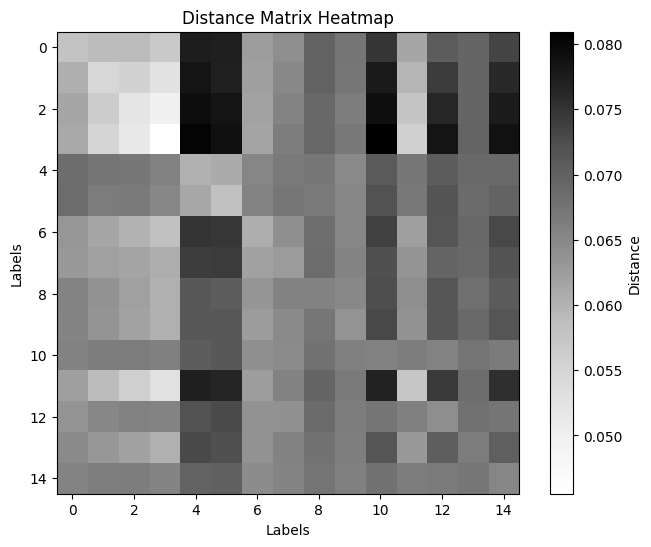

In [19]:
distance_matrix_normalized = distance_matrix / distance_matrix.sum(axis=1, keepdims=True)

epsilon = 1e-10
distance_matrix_reciprocal = 1 / (distance_matrix_normalized + epsilon)



plt.figure(figsize=(8, 6))
plt.imshow(distance_matrix_normalized, cmap='Greys', interpolation='nearest')
plt.colorbar(label='Distance')
plt.title('Distance Matrix Heatmap')
plt.xlabel('Labels')
plt.ylabel('Labels')

# Show the plot
plt.show()